# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [4]:
from google.colab import drive
import os

drive.mount('/content/drive')
practice_dir_path = '/content/drive/MyDrive/2025-Murzin-TimeSeriesCourse-main/practice/05 Snippets'
os.chdir(practice_dir_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pwd

/content/drive/MyDrive/2025-Murzin-TimeSeriesCourse-main/practice/05 Snippets


In [ ]:
#%load_ext autoreload
#%autoreload 2

Импорт библиотек и модулей

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

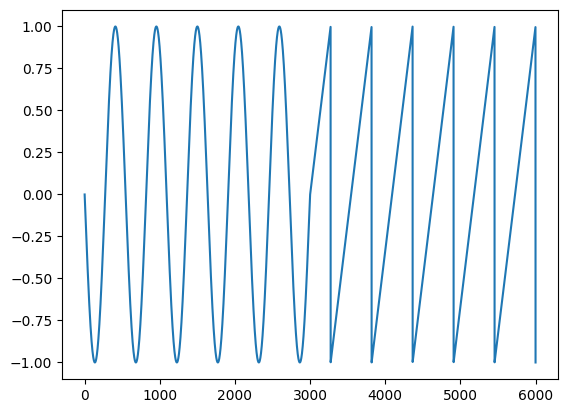

In [7]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [8]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


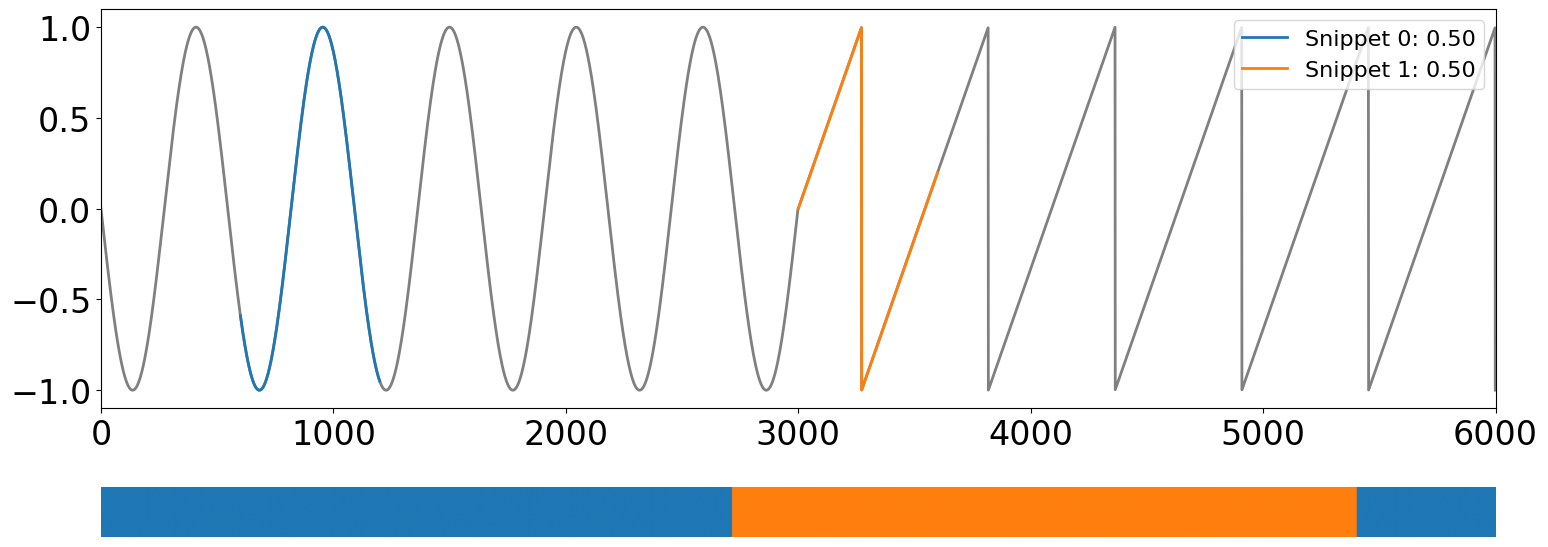

<Axes: >

In [9]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [21]:
# INSERT YOUR CODE

data_path = 'datasets/PAMAP/PAMAP.txt'
pamap = np.loadtxt(data_path)

timestamps = pamap[0]
gyroscope_data = pamap[11]
activity_ids = pamap[1]

gyroscope_data = gyroscope_data[np.where((timestamps >= 1790) & (timestamps <= 1930))]

snp = snippets(gyroscope_data, 600, 2, percentage=0.5)


Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

600


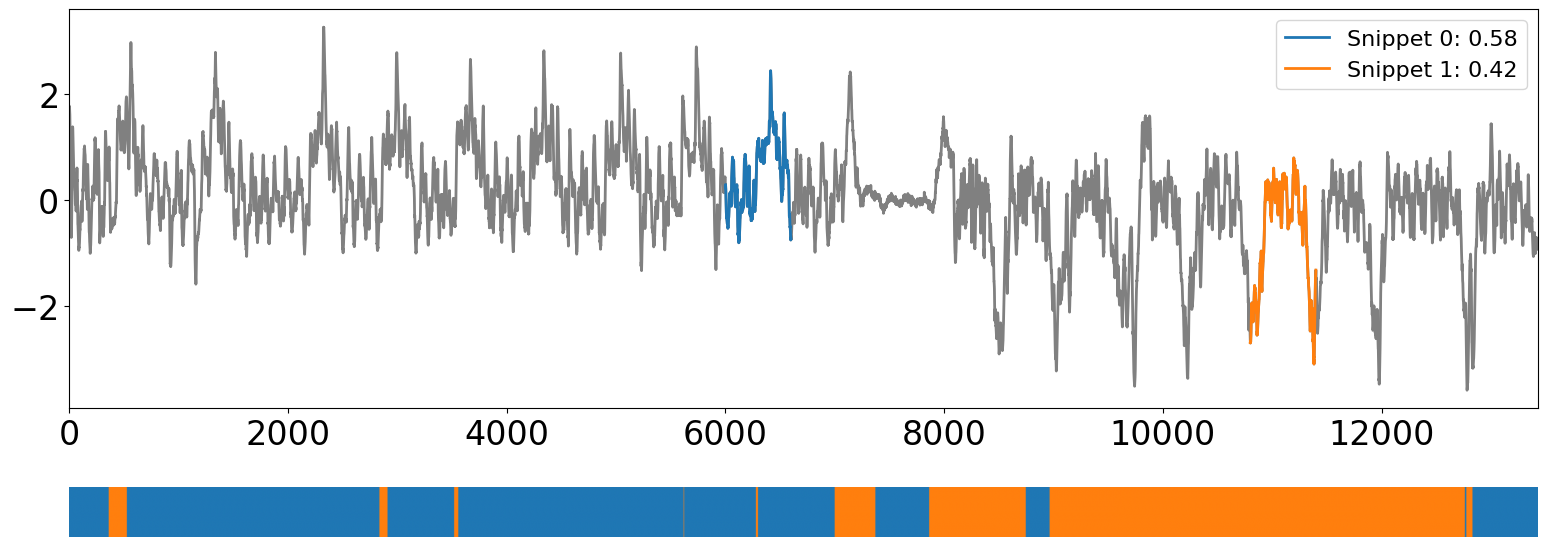

<Axes: >

In [13]:
# INSERT YOUR CODE
plot_snippets(gyroscope_data, snp)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [15]:
# INSERT YOUR CODE
from sklearn.metrics import accuracy_score

filtered_activity_ids = activity_ids[np.where((timestamps >= 1790) &  (timestamps <= 1930))]
filtered_activity_ids -= filtered_activity_ids.min()
snp_activity_ids = np.zeros(len(filtered_activity_ids))
for value, start, end in snp[-1]:
    snp_activity_ids[start:end] = value

# Оценка точности
acc = accuracy_score(filtered_activity_ids, snp_activity_ids)
print(f"Точность: {(acc*100):.2f}%")

Точность: 86.35%


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

На участке временного ряда с 1790 по 1930 секунд алгоритм обнаружил две различные, но равновероятные модели поведения системы по углу тангажа. Так как модели имеют высокую точность, означает, чт огироскоп зафиксировал устойчивый повторяющийся процесс, скорее всего управляемый человеком или автоматической системой, а не случайные колебания

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

600


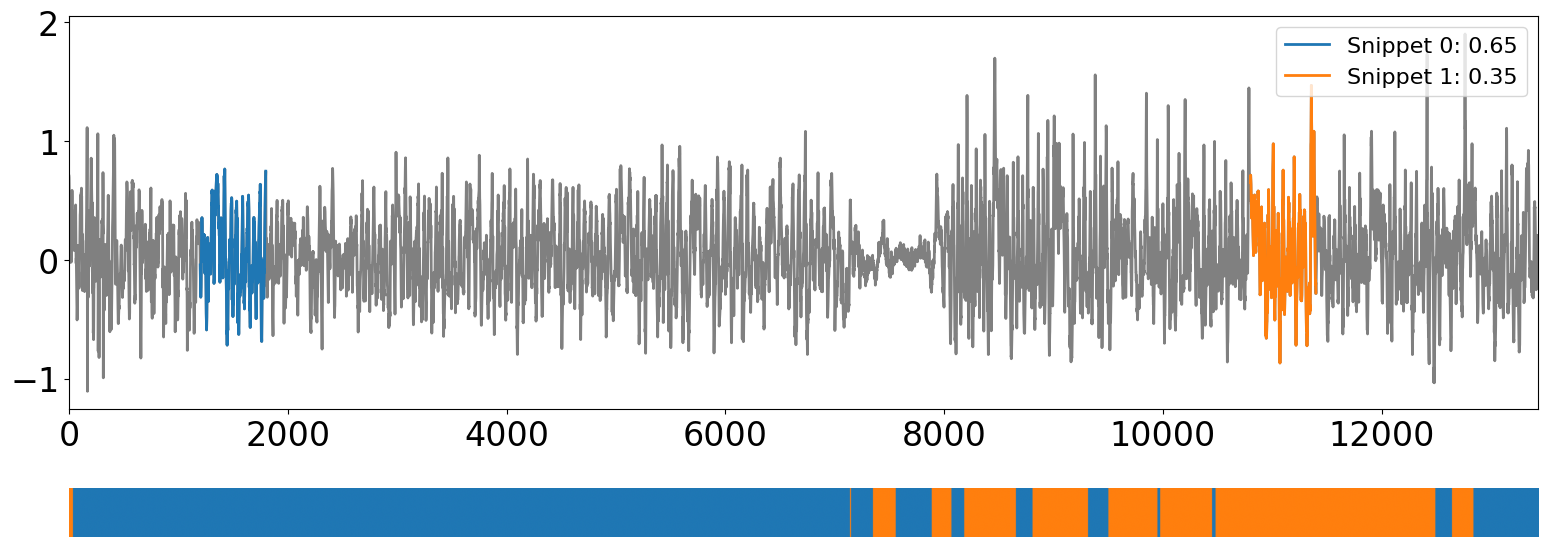

600


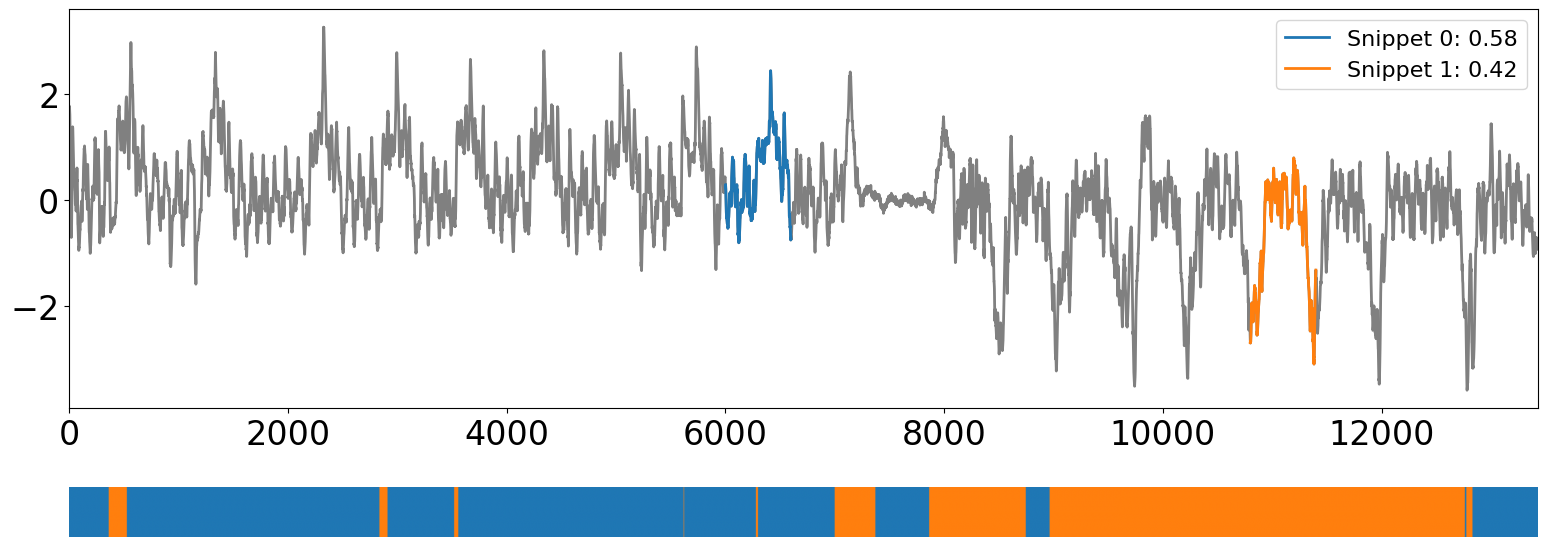

600


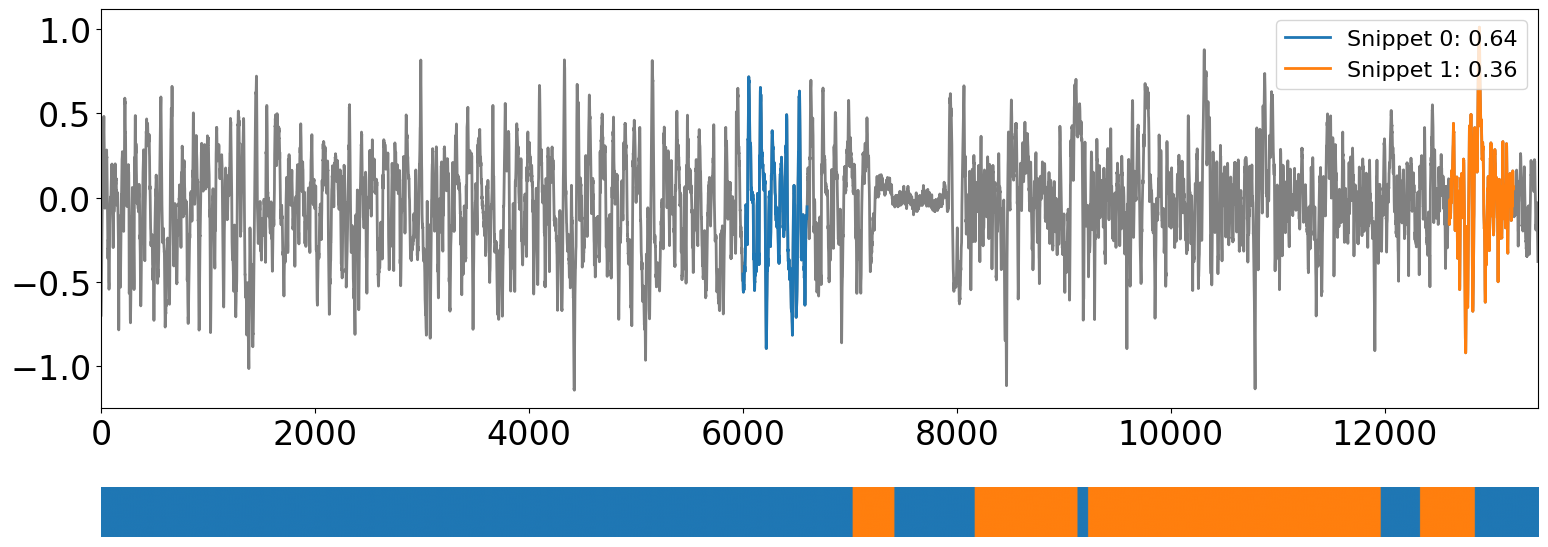

In [24]:
# INSERT YOUR CODE

timestamps = pamap[0]
gyro_x = pamap[10]
gyro_y = pamap[11]
gyro_z = pamap[12]
activity_ids = pamap[1]

filtered_timestamps = timestamps[(timestamps >= 1790) &  (timestamps <= 1930)]
gyro_x_filtered = gyro_x[(timestamps >= 1790) &  (timestamps <= 1930)]
gyro_y_filtered = gyro_y[(timestamps >= 1790) &  (timestamps <= 1930)]
gyro_z_filtered = gyro_z[(timestamps >= 1790) &  (timestamps <= 1930)]

filtered_activity_ids = activity_ids[np.where((timestamps >= 1790) &  (timestamps <= 1930))]
filtered_activity_ids -= filtered_activity_ids.min()

snp_x = snippets(gyro_x_filtered, 600, 2, percentage=0.5)
snp_y = snippets(gyro_y_filtered, 600, 2, percentage=0.5)
snp_z = snippets(gyro_z_filtered, 600, 2, percentage=0.5)

for data, snp in zip((gyro_x_filtered, gyro_y_filtered, gyro_z_filtered), (snp_x, snp_y, snp_z)):
    plot_snippets(data, snp)

snp_activity_ids_x = np.zeros(len(gyro_x_filtered))
snp_activity_ids_y = np.zeros(len(gyro_y_filtered))
snp_activity_ids_z = np.zeros(len(gyro_z_filtered))

for value, stat, end in snp_x[-1]:
    snp_activity_ids_x[start:end] = value

for value, stat, end in snp_y[-1]:
    snp_activity_ids_y[start:end] = value

for value, stat, end in snp_z[-1]:
    snp_activity_ids_z[start:end] = value

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [26]:
# INSERT YOUR CODE
final_activity_ids = []
for i in range(len(gyro_x_filtered)):
    votes = [snp_activity_ids_x[i], snp_activity_ids_y[i], snp_activity_ids_z[i]]
    final_activity_ids.append(np.bincount(votes).argmax())

final_activity_ids = np.array(final_activity_ids)

# Оценка точности
acc = accuracy_score(filtered_activity_ids, final_activity_ids)
print(f"Точность: {(acc*100):.2f}%")

Точность: 88.91%


❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

Алгоритм успешно обнаружил в данных гироскопа два устойчивых паттерна движения (подпоследовательности), которые с высокой точностью описывают поведение системы на заданном интервале времени. Это подтверждает, что комбинированные данные с разных осей дают более точную и устойчивую разметку, снижая влияние ошибок и шумов.

## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [32]:
# INSERT YOUR CODE

import pandas as pd
from stumpy import snippets

df = pd.read_csv(r'datasets/PAMAP/PAMAP.txt', sep=' ', header=None).T
start_time = 1900
end_time = 1930

ts = df.loc[start_time < df.iloc[:,0]].loc[df.iloc[:,0] < end_time].iloc[:,10].to_numpy()

k = 9
snip = snippets(ts, 500, k)
prof_area = snip[4]

change = []
for i in range(1,9):
    change.append(prof_area[i-1] / prof_area[i] - 1)

In [33]:
change

[np.float64(0.06382069137333701),
 np.float64(0.024959276026546462),
 np.float64(0.014870149108661357),
 np.float64(0.01226450100583576),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

In [36]:
# INSERT YOUR CODE

df_an = pd.DataFrame({
    'k': list(range(1, 10)),
    'ProfileArea': prof_area,
    'Change': [None] + change
})

df_an['Change'] = df_an['Change'].fillna(0)
df_an

,k,ProfileArea,Change
0,1,78621.191857,0.000000
1,2,73904.552237,0.063821
2,3,72104.866960,0.024959
3,4,71048.367147,0.014870
4,5,70187.551846,0.012265
5,6,70187.551846,0.000000
6,7,70187.551846,0.000000
7,8,70187.551846,0.000000
8,9,70187.551846,0.000000


In [39]:
max_change_idx = np.argmax(change)
optimal_k = max_change_idx + 2

print(f"Максимальное улучшение: {change[max_change_idx]:.6f} при k={optimal_k}")
print(f'Это означает, что переход от k={optimal_k-1} к k={optimal_k} даёт наибольшее относительное улучшение')

Максимальное улучшение: 0.063821 при k=2
Это означает, что переход от k=1 к k=2 даёт наибольшее относительное улучшение


In [40]:
if len(change) > 2:
    changes_diff = np.diff(change)
    stab_point = None

    for i in range(len(changes_diff)):
        if changes_diff[i] < 0.1 * max(change):
            stab_point = i + 3
            break

    if stab_point:
        print(f"Стабилизация улучшения начинается с k={stab_point}")
        print(" *дальнейшие увеличение k даёт незначительное улучшение")

Стабилизация улучшения начинается с k=3
 *дальнейшие увеличение k даёт незначительное улучшение


In [46]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('ProfileArea в зависимости от k', 'Мера Change в зависимости от k'),
    vertical_spacing=0.1
)

fig.add_trace(
    go.Bar(x=list(range(1, 10)), y=prof_area,
          name='ProfileArea', marker_color='lightblue',
          text=[f'{x:.4f}' for x in prof_area], textposition='auto'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=list(range(2, 18)), y=change,
          name='Change', marker_color='yellow',
          text=[f'{x:.4f}' for x in change], textposition='auto'),
    row=2, col=1
)

fig.update_xaxes(title_text="k", row=1, col=1)
fig.update_xaxes(title_text="k", row=1, col=1)
fig.update_yaxes(title_text="ProfileArea", row=1, col=1)
fig.update_yaxes(title_text="Change", row=2, col=1)

fig.update_layout(height=800, showlegend=False)
fig.show()

In [48]:
print(f"Оптимальное значение k: {optimal_k}\nОбоснование:\n- Наибольшее относительное улучшение качетсва достигается при k={optimal_k}\n- ProfileArea улучшается с {prof_area[optimal_k-2]:.6f} до {prof_area[optimal_k-1]:.6f}\n- Относительное улучшение: {change[optimal_k-2]:.2%}")

Оптимальное значение k: 2
Обоснование:
- Наибольшее относительное улучшение качетсва достигается при k=2
- ProfileArea улучшается с 78621.191857 до 73904.552237
- Относительное улучшение: 6.38%


❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?

Оптимальное значение k: 2